In [37]:
!pip install focal-loss

In [38]:
import tensorflow as tf
from tensorflow.keras import layers, applications, callbacks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from focal_loss import SparseCategoricalFocalLoss
import gc

In [39]:
SEED = 24520152

In [40]:
tf.keras.utils.set_random_seed(SEED)

In [41]:
TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [42]:
SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [43]:
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [44]:
model_name = 'ResNet50'
model_name

'ResNet50'

In [45]:
preprocess_fn = applications.resnet.preprocess_input

In [46]:
def build_data_augmentation(SEED=24520152):
    """Create a simple data augmentation pipeline"""
    return tf.keras.Sequential([
        layers.RandomFlip('horizontal', seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        layers.RandomZoom(0.1, seed=SEED),
        layers.RandomContrast(0.1, seed=SEED),
        layers.RandomBrightness(0.1, seed=SEED),
    ], name='data_augmentation')

In [47]:
def get_data_for_fold(k, preprocess_fn, train_dir=TRAIN_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, SEED=24520152):
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]
    
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )
    
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dirs[0],
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    )
    
    for directory in train_dirs[1:]:
        ds_part = tf.keras.utils.image_dataset_from_directory(
            directory,
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED,
        )
        train_ds = train_ds.concatenate(ds_part)

    train_ds = train_ds.shuffle(buffer_size=3000, seed=SEED)
    
    AUTOTUNE = tf.data.AUTOTUNE
    data_augmentation = build_data_augmentation()

    def augment_and_preprocess_train(image, label):
        """Apply augmentation and preprocessing to the training set"""
        image = data_augmentation(image, training=True)
        image = preprocess_fn(image)
        return image, label

    def preprocess_val(image, label):
        """Apply preprocessing to the validation set (no augmentation)"""
        image = preprocess_fn(image)
        return image, label

    train_ds = train_ds.map(augment_and_preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.map(preprocess_val, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds

In [48]:
def build_resnet50(INPUT_SHAPE=(224, 224, 3), NUM_CLASSES=3, DROPOUT_RATE=0.3):
    """
    Build a ResNet50 model with a custom head for classification
    This uses feature extraction (freezing the backbone)

    Args:
        INPUT_SHAPE (tuple): The shape of the input images
        NUM_CLASSES (int): The number of output classes
        DROPOUT_RATE (float): Dropout rate for the classifier head

    Returns:
        tf.keras.Model: The compiled Keras model
    """
    input_layer = tf.keras.Input(shape=INPUT_SHAPE, name="input_layer")

    backbone = applications.ResNet50(
        include_top=False,
        weights='imagenet',
    )
    backbone.trainable = False

    x = backbone(input_layer, training=False)
    x = layers.GlobalAveragePooling2D(name='pooling_layer')(x)
    x = layers.Dropout(DROPOUT_RATE, name='dropout_layer')(x)
    output_layer = layers.Dense(NUM_CLASSES, activation='softmax', name='output_layer')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name=model_name)
    return model

In [49]:
def train_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50):
    # Build model
    model = build_resnet50()
    print(model.summary())

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    # Set up callbacks
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.keras')

    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    # Train model
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return history

In [50]:
def test_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    # history = train_classifier(
    #     train_ds=train_ds,
    #     val_ds=val_ds,
    #     preprocess_fn=preprocess_fn,
    #     fold_k=fold_k,
    # )

    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_6_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    del model, results, loss, results_df, y_true, y_pred, cm
    tf.keras.backend.clear_session()
    gc.collect()

    return acc

In [51]:
def train_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50, LEARNING_RATE=0.00001):
    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_{block + 1}_fold_{fold_k}.keras')
    print(model.summary())
    
    backbone = model.get_layer('resnet50')
    backbone.trainable = True
    
    set_trainable = False
    if block == 1:
        set_trainable = True
    for layer in backbone.layers:
        if layer.name == f'conv{block}_block1_1_conv':
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.keras')
    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return history

In [52]:
def test_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    # history = train_block(
    #     train_ds=train_ds,
    #     val_ds=val_ds,
    #     preprocess_fn=preprocess_fn,
    #     fold_k=fold_k,
    #     block=block,
    # )

    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_{block}_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    del model, results, loss, results_df, y_true, y_pred, cm
    tf.keras.backend.clear_session()
    gc.collect()

    return acc

In [53]:
acc_b6 = []
acc_b5 = []
acc_b4 = []
acc_b3 = []
acc_b2 = []
acc_b1 = []

Fold: 1 block 6
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 173ms/step - accuracy: 0.9413 - loss: 0.0513
      Model      Loss  Accuracy
0  ResNet50  0.074978  0.920664
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 281ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.95      0.94       245
Meningioma Tumor       0.84      0.80      0.82       112
 Pituitary Tumor       0.96      0.96      0.96       185

        accuracy                           0.92       542
       macro avg       0.91      0.90      0.91       542
    weighted avg       0.92      0.92      0.92       542



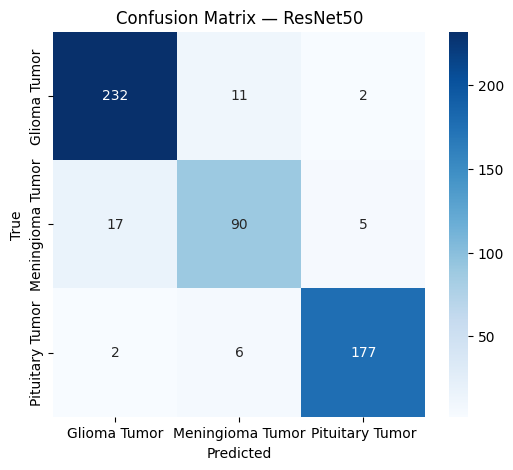

Fold: 1 block 5
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.9675 - loss: 0.0309
      Model      Loss  Accuracy
0  ResNet50  0.049718  0.950185
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 280ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.97      0.96       245
Meningioma Tumor       0.92      0.87      0.89       112
 Pituitary Tumor       0.96      0.97      0.97       185

        accuracy                           0.95       542
       macro avg       0.94      0.94      0.94       542
    weighted avg       0.95      0.95      0.95       542



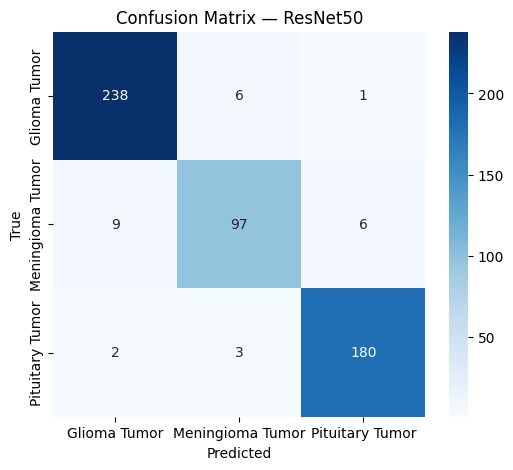

Fold: 1 block 4
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.9741 - loss: 0.0311
      Model      Loss  Accuracy
0  ResNet50  0.051846   0.95941
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 281ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       245
Meningioma Tumor       0.93      0.89      0.91       112
 Pituitary Tumor       0.98      0.97      0.98       185

        accuracy                           0.96       542
       macro avg       0.96      0.95      0.95       542
    weighted avg       0.96      0.96      0.96       542



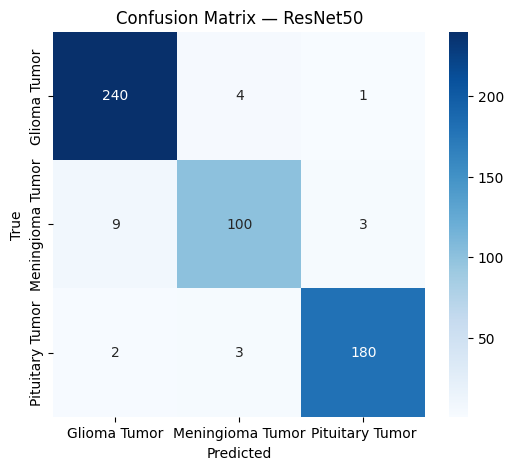

Fold: 1 block 3
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.9751 - loss: 0.0320
      Model      Loss  Accuracy
0  ResNet50  0.048779    0.9631
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 291ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       245
Meningioma Tumor       0.97      0.88      0.92       112
 Pituitary Tumor       0.97      0.99      0.98       185

        accuracy                           0.96       542
       macro avg       0.96      0.95      0.96       542
    weighted avg       0.96      0.96      0.96       542



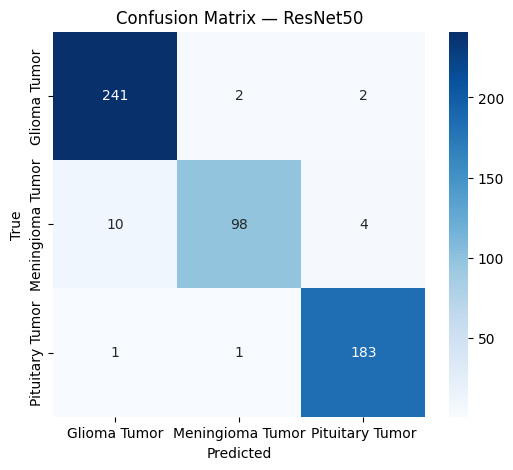

Fold: 1 block 2
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.9796 - loss: 0.0335
      Model      Loss  Accuracy
0  ResNet50  0.053142   0.96679
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 290ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.99      0.97       245
Meningioma Tumor       0.98      0.88      0.93       112
 Pituitary Tumor       0.98      0.98      0.98       185

        accuracy                           0.97       542
       macro avg       0.97      0.95      0.96       542
    weighted avg       0.97      0.97      0.97       542



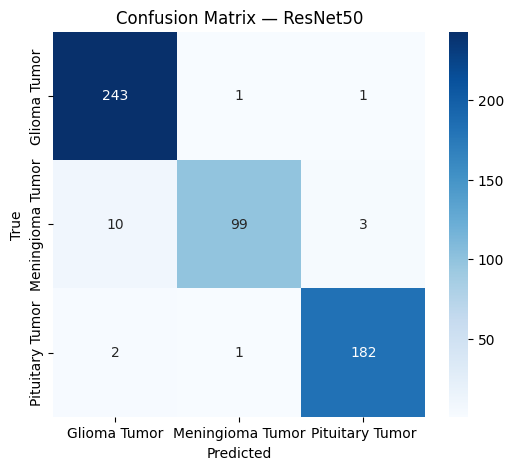

Fold: 1 block 1
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.9800 - loss: 0.0315
      Model      Loss  Accuracy
0  ResNet50  0.045223  0.972325
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 284ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       245
Meningioma Tumor       0.96      0.92      0.94       112
 Pituitary Tumor       0.97      1.00      0.98       185

        accuracy                           0.97       542
       macro avg       0.97      0.97      0.97       542
    weighted avg       0.97      0.97      0.97       542



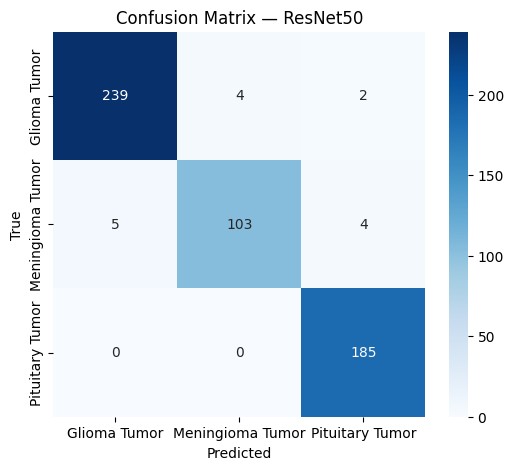

Fold: 2 block 6
Found 679 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.8827 - loss: 0.1025
      Model      Loss  Accuracy
0  ResNet50  0.141036  0.835052
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.84      0.91      0.88       338
Meningioma Tumor       0.73      0.59      0.65       167
 Pituitary Tumor       0.91      0.91      0.91       174

        accuracy                           0.84       679
       macro avg       0.83      0.81      0.81       679
    weighted avg       0.83      0.84      0.83       679



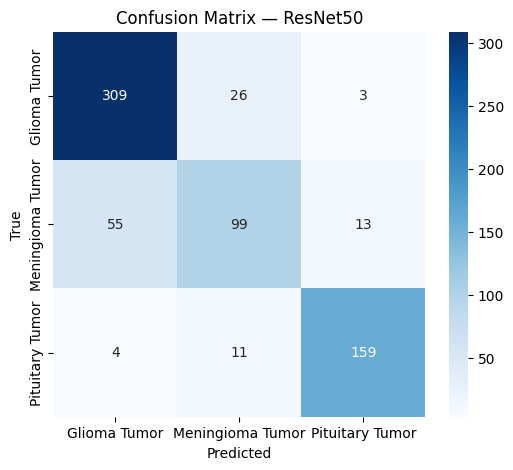

Fold: 2 block 5
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.9010 - loss: 0.1098
      Model      Loss  Accuracy
0  ResNet50  0.153863  0.863034
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.93      0.90       338
Meningioma Tumor       0.82      0.63      0.72       167
 Pituitary Tumor       0.88      0.96      0.92       174

        accuracy                           0.86       679
       macro avg       0.86      0.84      0.84       679
    weighted avg       0.86      0.86      0.86       679



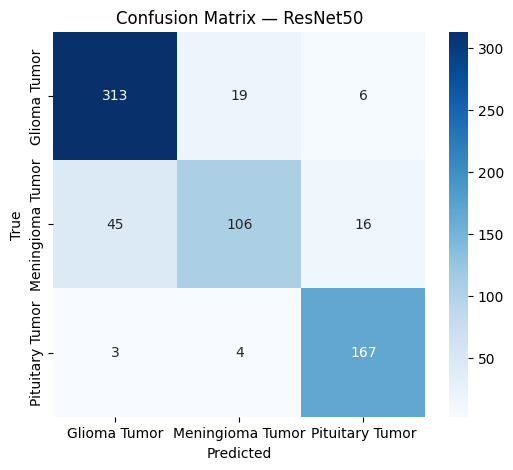

Fold: 2 block 4
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.9149 - loss: 0.1273
      Model      Loss  Accuracy
0  ResNet50  0.193149  0.873343
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.86      0.95      0.90       338
Meningioma Tumor       0.88      0.67      0.76       167
 Pituitary Tumor       0.89      0.91      0.90       174

        accuracy                           0.87       679
       macro avg       0.88      0.85      0.86       679
    weighted avg       0.87      0.87      0.87       679



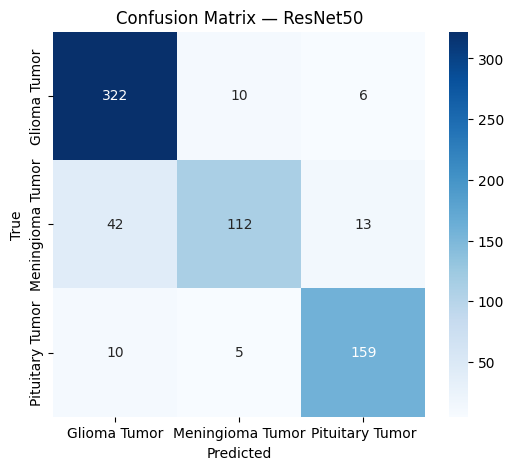

Fold: 2 block 3
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.9314 - loss: 0.1102
      Model      Loss  Accuracy
0  ResNet50  0.215489  0.876289
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 233ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.86      0.96      0.91       338
Meningioma Tumor       0.85      0.73      0.79       167
 Pituitary Tumor       0.94      0.84      0.89       174

        accuracy                           0.88       679
       macro avg       0.88      0.85      0.86       679
    weighted avg       0.88      0.88      0.87       679



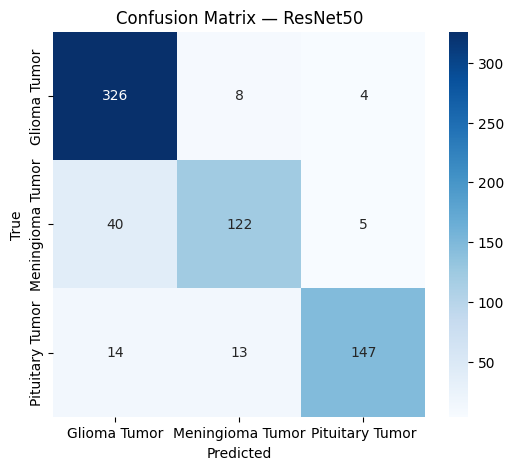

Fold: 2 block 2
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.9231 - loss: 0.1319
      Model      Loss  Accuracy
0  ResNet50  0.180159  0.892489
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.94      0.93       338
Meningioma Tumor       0.89      0.70      0.79       167
 Pituitary Tumor       0.86      0.98      0.91       174

        accuracy                           0.89       679
       macro avg       0.89      0.87      0.88       679
    weighted avg       0.89      0.89      0.89       679



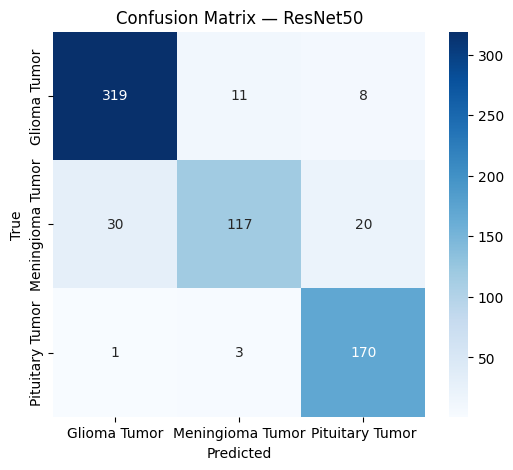

Fold: 2 block 1
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.9220 - loss: 0.1296
      Model      Loss  Accuracy
0  ResNet50  0.157466  0.901325
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.90      0.94      0.92       338
Meningioma Tumor       0.87      0.79      0.83       167
 Pituitary Tumor       0.92      0.93      0.93       174

        accuracy                           0.90       679
       macro avg       0.90      0.89      0.89       679
    weighted avg       0.90      0.90      0.90       679



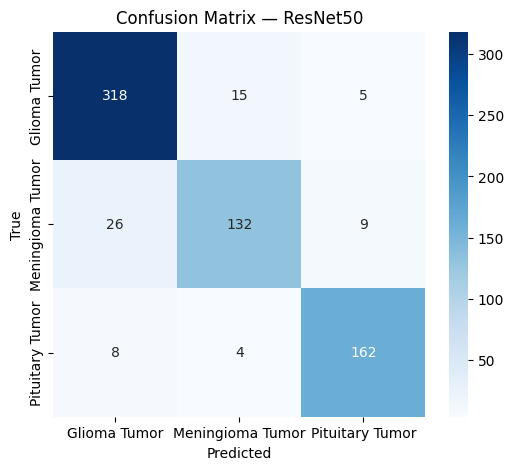

Fold: 3 block 6
Found 572 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.8812 - loss: 0.1034
      Model     Loss  Accuracy
0  ResNet50  0.11408  0.868881
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 276ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.88      0.86      0.87       231
Meningioma Tumor       0.78      0.70      0.73       139
 Pituitary Tumor       0.91      1.00      0.95       202

        accuracy                           0.87       572
       macro avg       0.86      0.85      0.85       572
    weighted avg       0.87      0.87      0.87       572



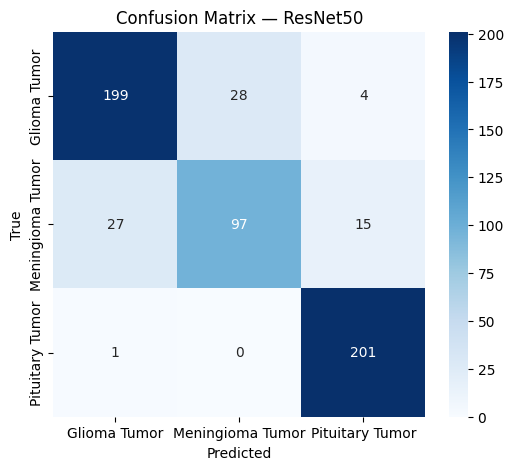

Fold: 3 block 5
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.8821 - loss: 0.1212
      Model      Loss  Accuracy
0  ResNet50  0.140307  0.867133
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 284ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.86      0.86       231
Meningioma Tumor       0.76      0.70      0.73       139
 Pituitary Tumor       0.93      0.99      0.96       202

        accuracy                           0.87       572
       macro avg       0.85      0.85      0.85       572
    weighted avg       0.86      0.87      0.86       572



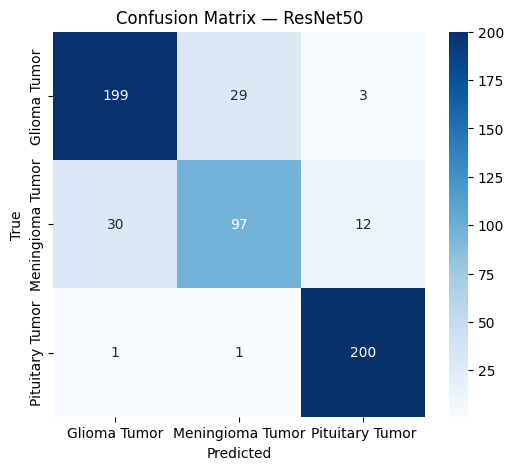

Fold: 3 block 4
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.9156 - loss: 0.1350
      Model      Loss  Accuracy
0  ResNet50  0.149223  0.907343
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 275ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.90      0.92       231
Meningioma Tumor       0.82      0.80      0.81       139
 Pituitary Tumor       0.93      1.00      0.96       202

        accuracy                           0.91       572
       macro avg       0.90      0.90      0.90       572
    weighted avg       0.91      0.91      0.91       572



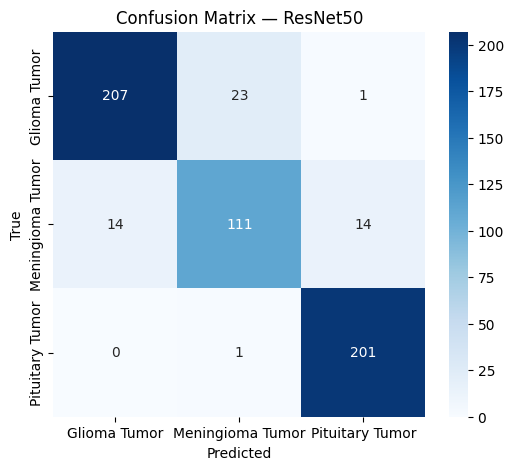

Fold: 3 block 3
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.9270 - loss: 0.1407
      Model     Loss  Accuracy
0  ResNet50  0.15582  0.912587
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 271ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.92      0.91       231
Meningioma Tumor       0.85      0.80      0.83       139
 Pituitary Tumor       0.95      0.99      0.97       202

        accuracy                           0.91       572
       macro avg       0.91      0.90      0.90       572
    weighted avg       0.91      0.91      0.91       572



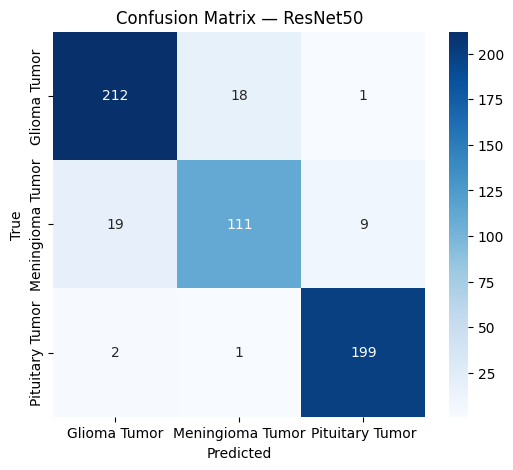

Fold: 3 block 2
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.9203 - loss: 0.1600
      Model      Loss  Accuracy
0  ResNet50  0.165138  0.912587
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.89      0.91       231
Meningioma Tumor       0.83      0.84      0.84       139
 Pituitary Tumor       0.94      0.99      0.96       202

        accuracy                           0.91       572
       macro avg       0.90      0.91      0.90       572
    weighted avg       0.91      0.91      0.91       572



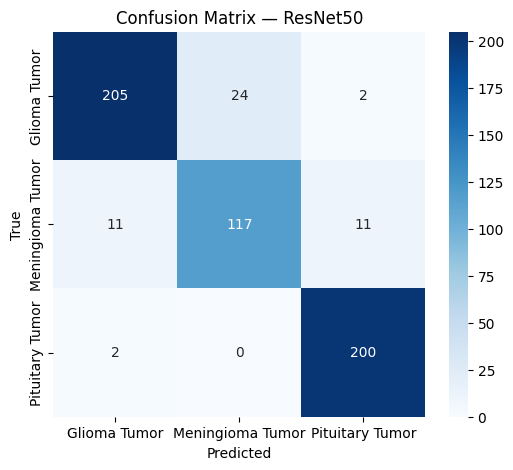

Fold: 3 block 1
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.9274 - loss: 0.1287
      Model      Loss  Accuracy
0  ResNet50  0.142726  0.912587
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 277ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.92      0.91       231
Meningioma Tumor       0.85      0.80      0.83       139
 Pituitary Tumor       0.97      0.98      0.98       202

        accuracy                           0.91       572
       macro avg       0.91      0.90      0.90       572
    weighted avg       0.91      0.91      0.91       572



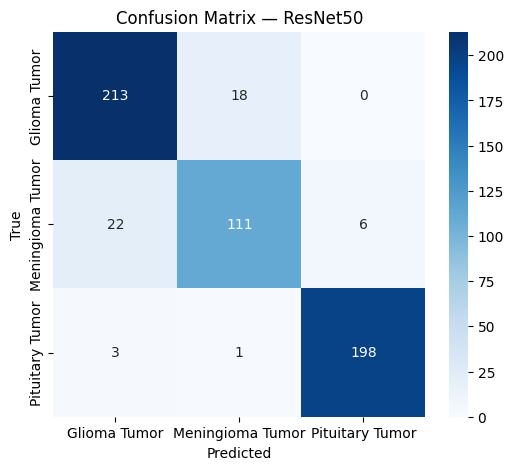

Fold: 4 block 6
Found 628 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9209 - loss: 0.0721
      Model      Loss  Accuracy
0  ResNet50  0.103289  0.899682
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 248ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.87      0.92       325
Meningioma Tumor       0.70      0.90      0.79       124
 Pituitary Tumor       0.95      0.94      0.95       179

        accuracy                           0.90       628
       macro avg       0.88      0.91      0.89       628
    weighted avg       0.91      0.90      0.90       628



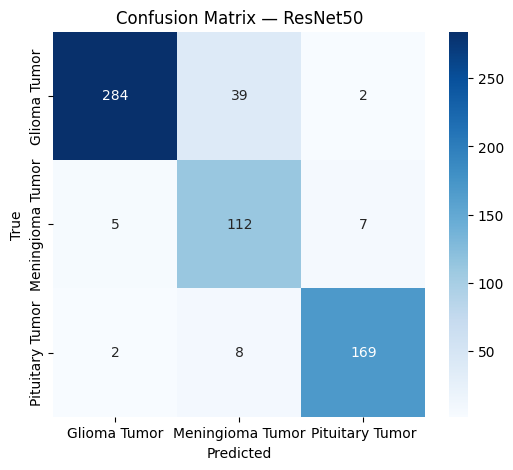

Fold: 4 block 5
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.9602 - loss: 0.0399
      Model      Loss  Accuracy
0  ResNet50  0.071986  0.937898
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.96      0.96       325
Meningioma Tumor       0.87      0.84      0.86       124
 Pituitary Tumor       0.94      0.97      0.95       179

        accuracy                           0.94       628
       macro avg       0.92      0.92      0.92       628
    weighted avg       0.94      0.94      0.94       628



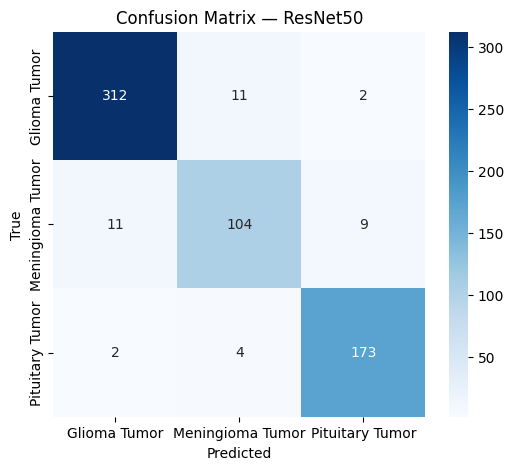

Fold: 4 block 4
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.9758 - loss: 0.0248
      Model      Loss  Accuracy
0  ResNet50  0.056923  0.947452
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 248ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      1.00      0.97       325
Meningioma Tumor       0.95      0.81      0.87       124
 Pituitary Tumor       0.96      0.95      0.96       179

        accuracy                           0.95       628
       macro avg       0.95      0.92      0.93       628
    weighted avg       0.95      0.95      0.95       628



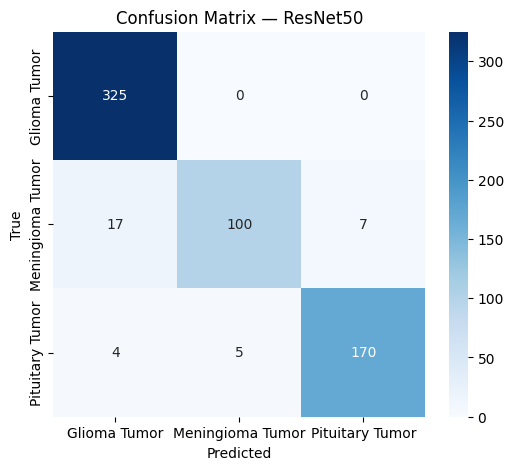

Fold: 4 block 3
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.9708 - loss: 0.0350
      Model      Loss  Accuracy
0  ResNet50  0.085579   0.93949
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      1.00      0.96       325
Meningioma Tumor       0.95      0.78      0.86       124
 Pituitary Tumor       0.95      0.94      0.95       179

        accuracy                           0.94       628
       macro avg       0.94      0.91      0.92       628
    weighted avg       0.94      0.94      0.94       628



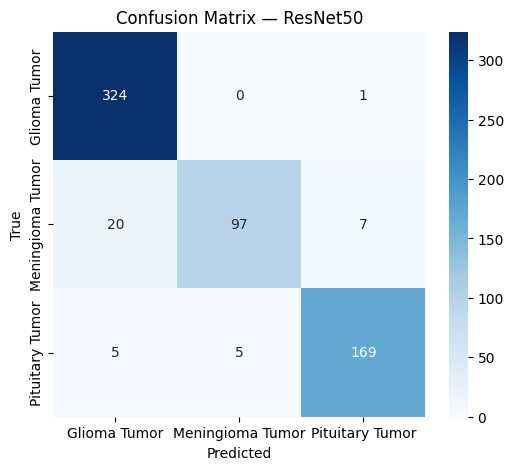

Fold: 4 block 2
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - accuracy: 0.9748 - loss: 0.0299
      Model      Loss  Accuracy
0  ResNet50  0.060646  0.950637
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.99      0.98       325
Meningioma Tumor       0.94      0.82      0.88       124
 Pituitary Tumor       0.92      0.96      0.94       179

        accuracy                           0.95       628
       macro avg       0.95      0.93      0.93       628
    weighted avg       0.95      0.95      0.95       628



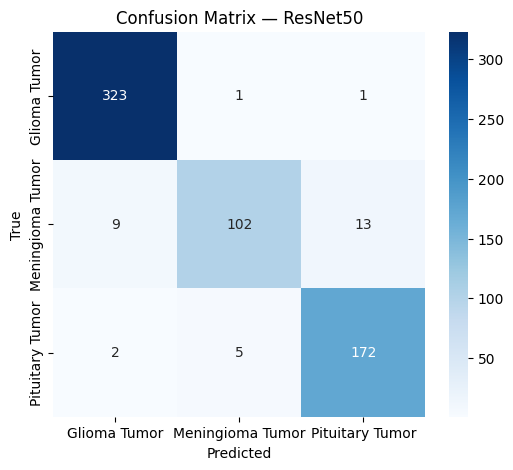

Fold: 4 block 1
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - accuracy: 0.9628 - loss: 0.0558
      Model      Loss  Accuracy
0  ResNet50  0.102668  0.934713
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.99      0.97       325
Meningioma Tumor       0.96      0.73      0.83       124
 Pituitary Tumor       0.89      0.97      0.93       179

        accuracy                           0.93       628
       macro avg       0.93      0.90      0.91       628
    weighted avg       0.94      0.93      0.93       628



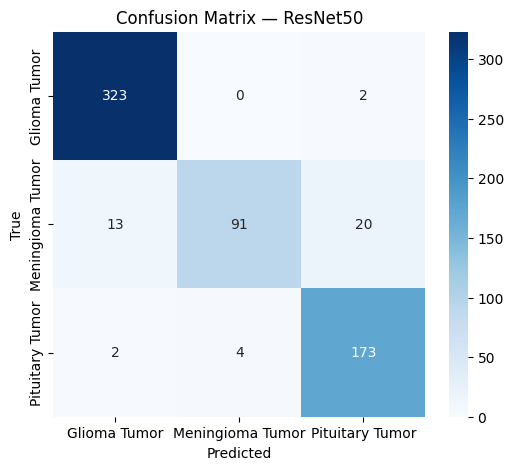

Fold: 5 block 6
Found 643 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.8498 - loss: 0.1712
      Model     Loss  Accuracy
0  ResNet50  0.21704  0.833593
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 241ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.88      0.90      0.89       287
Meningioma Tumor       0.74      0.58      0.65       166
 Pituitary Tumor       0.83      0.96      0.89       190

        accuracy                           0.83       643
       macro avg       0.82      0.81      0.81       643
    weighted avg       0.83      0.83      0.83       643



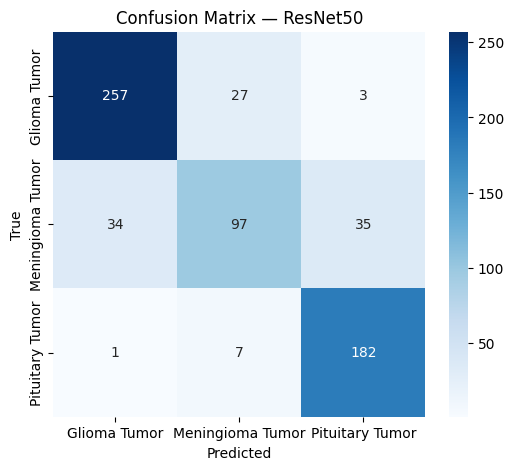

Fold: 5 block 5
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.8736 - loss: 0.1965
      Model      Loss  Accuracy
0  ResNet50  0.268198  0.858476
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.93      0.91       287
Meningioma Tumor       0.83      0.60      0.69       166
 Pituitary Tumor       0.83      0.98      0.90       190

        accuracy                           0.86       643
       macro avg       0.85      0.84      0.83       643
    weighted avg       0.86      0.86      0.85       643



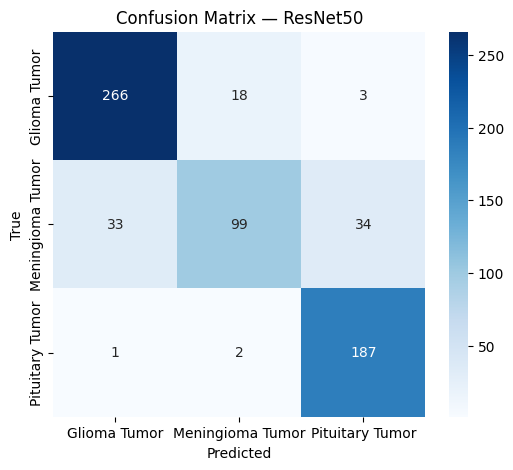

Fold: 5 block 4
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.9044 - loss: 0.1991
      Model      Loss  Accuracy
0  ResNet50  0.292474  0.881804
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.94      0.93       287
Meningioma Tumor       0.87      0.66      0.75       166
 Pituitary Tumor       0.84      0.99      0.91       190

        accuracy                           0.88       643
       macro avg       0.88      0.86      0.86       643
    weighted avg       0.88      0.88      0.88       643



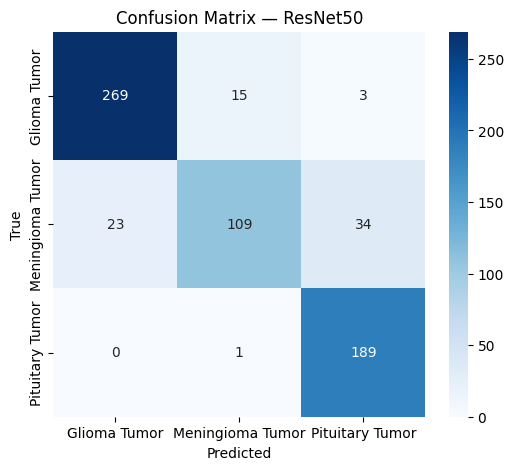

Fold: 5 block 3
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.9102 - loss: 0.1816
      Model      Loss  Accuracy
0  ResNet50  0.296805    0.8507
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.82      0.97      0.89       287
Meningioma Tumor       0.87      0.55      0.68       166
 Pituitary Tumor       0.89      0.93      0.91       190

        accuracy                           0.85       643
       macro avg       0.86      0.82      0.83       643
    weighted avg       0.85      0.85      0.84       643



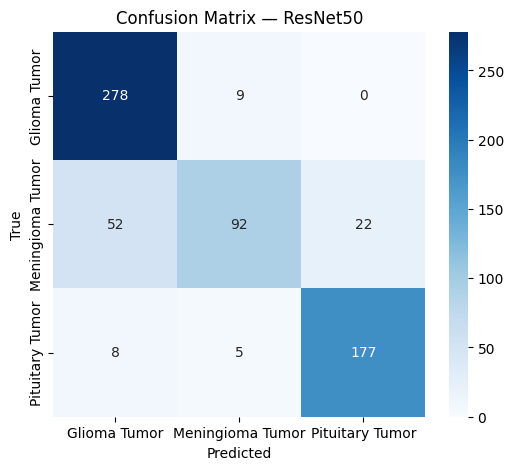

Fold: 5 block 2
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.9124 - loss: 0.2697
      Model      Loss  Accuracy
0  ResNet50  0.402739  0.872473
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 229ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.97      0.94       287
Meningioma Tumor       0.93      0.57      0.70       166
 Pituitary Tumor       0.79      1.00      0.89       190

        accuracy                           0.87       643
       macro avg       0.88      0.84      0.84       643
    weighted avg       0.88      0.87      0.86       643



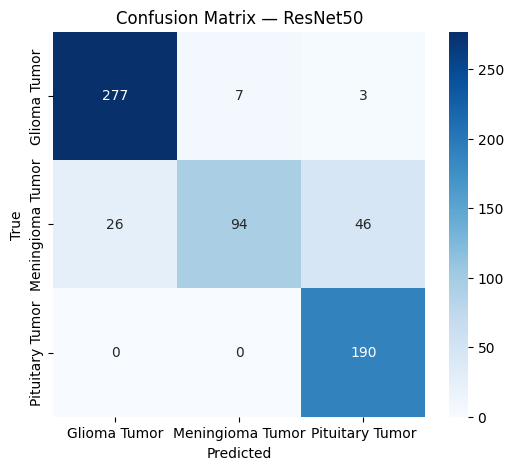

Fold: 5 block 1
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.9103 - loss: 0.2335
      Model      Loss  Accuracy
0  ResNet50  0.336494  0.878694
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.94      0.93       287
Meningioma Tumor       0.89      0.64      0.75       166
 Pituitary Tumor       0.82      0.98      0.89       190

        accuracy                           0.88       643
       macro avg       0.88      0.86      0.86       643
    weighted avg       0.88      0.88      0.87       643



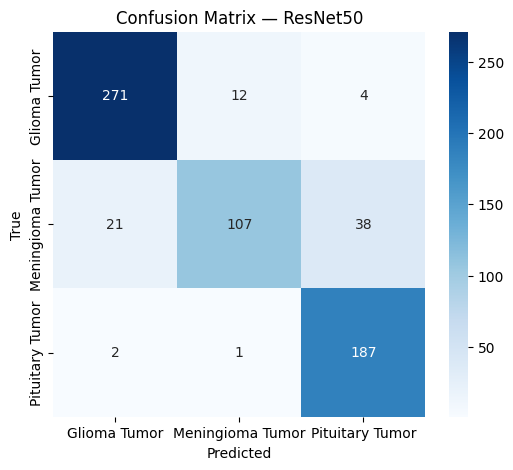

In [54]:
for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 6')
    train_ds, val_ds = get_data_for_fold(fold_k, preprocess_fn)
    
    acc_b6.append(test_classifier(train_ds, val_ds, preprocess_fn, fold_k))
    tf.keras.backend.clear_session()
    gc.collect()

    for block in range(5, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_ds, val_ds, preprocess_fn, fold_k, block))
        tf.keras.backend.clear_session()
        gc.collect()
    
    del train_ds, val_ds
    gc.collect()

In [55]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]
ACC_BLOCK

[[0.9206641912460327,
  0.8350515365600586,
  0.868881106376648,
  0.8996815085411072,
  0.8335925340652466],
 [0.9501845240592957,
  0.8630338907241821,
  0.867132842540741,
  0.9378980994224548,
  0.858475923538208],
 [0.9594095945358276,
  0.8733431696891785,
  0.9073426723480225,
  0.9474522471427917,
  0.8818040490150452],
 [0.9630996584892273,
  0.876288652420044,
  0.9125874042510986,
  0.9394904375076294,
  0.8506998419761658],
 [0.9667896628379822,
  0.892488956451416,
  0.9125874042510986,
  0.9506369233131409,
  0.8724727630615234],
 [0.9723247289657593,
  0.9013254642486572,
  0.9125874042510986,
  0.9347133636474609,
  0.8786936402320862]]

In [56]:
for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 87.16%
Accuracy unfreeze block 5 - block 6: 89.53%
Accuracy unfreeze block 4 - block 6: 91.39%
Accuracy unfreeze block 3 - block 6: 90.84%
Accuracy unfreeze block 2 - block 6: 91.90%
Accuracy unfreeze block 1 - block 6: 91.99%
